# Flat → variable-slope online CPG adaptation — analysis

Reads the per-run signals written by `run_experiment.py` (`results/manifest.csv`
+ `results/runs/*.npz` + `results/config.json`) and builds the method comparison.

**Scenario.** The robot walks on flat ground with the **flat-optimal** CPG gait.
Five metres in, the terrain rises at a slope of variable degree. A MARX-EFE agent
monitors the **prediction error** every step (goal cross-entropy between its
one-step posterior predictive and a stable-walking goal prior; normalised to the
flat baseline it is ≈1 on the flat prefix). When that ratio exceeds `K` an
**event** fires and an online method starts searching for new CPG parameters,
window by window. Adaptation runs only **while** the error is above `K`; once a
window comes back below `K` the method **pauses** (squash-to-stop).

**Methods (arms).** `noadapt` (hold flat gait) and `oracle` (jump to the
slope-optimal gait) are anchors; `grid`, `bo`, `marxefe` are the online searchers
(all three wrapped in the shared revert-to-best safeguard).

## 1. Load results

In [1]:
import os, sys, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

HERE = os.getcwd()
RESULTS = os.path.join(HERE, "results")
if not os.path.isdir(RESULTS):                       # allow running from repo root
    RESULTS = os.path.join(HERE, "experiment-flat2slope-adapt", "results")

with open(os.path.join(RESULTS, "config.json")) as f:
    CFG = json.load(f)
DT = CFG["dt"]; K = CFG["k_sigma"]; SLOPE_START_Y = CFG["slope_start_y"]
manifest = pd.read_csv(os.path.join(RESULTS, "manifest.csv"))

ARMS   = [a for a in ["noadapt", "oracle", "grid", "bo", "marxefe"]
          if a in manifest["method"].unique()]
SLOPES = sorted(manifest["slope_deg"].unique())
SEEDS  = sorted(manifest["seed"].unique())
COLOR  = {"noadapt": "#8a8984", "oracle": "#c79a00", "grid": "#2a78d6",
          "bo": "#eb6834", "marxefe": "#2ca02c"}
PARAM_NAMES = ["coupling_gain", "w_swing", "w_stance", "F_FAST",
               "STOP_GAIN", "hip_amp", "knee_amp", "b"]

def load_run(slope, seed, method):
    """Load one run's NPZ as a dict of arrays."""
    path = os.path.join(RESULTS, "runs", f"slope{slope:g}_seed{seed}_{method}.npz")
    d = np.load(path, allow_pickle=True)
    return {k: d[k] for k in d.files}

def onset_step(r):
    """First step the base crosses onto the incline (y >= 5 m)."""
    idx = np.nonzero(r["y"] >= SLOPE_START_Y)[0]
    return int(idx[0]) if len(idx) else None

print(f"slopes={SLOPES}  seeds={SEEDS}  arms={ARMS}  K={K:.3g}")
print(f"incumbent (flat-opt): {np.round(CFG['incumbent'],3).tolist()}")
print(f"oracle   (slope-opt): {np.round(CFG['oracle'],3).tolist()}")
manifest

slopes=[np.float64(10.0), np.float64(15.0)]  seeds=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]  arms=['noadapt', 'oracle', 'grid', 'bo', 'marxefe']  K=2
incumbent (flat-opt): [9.357, 10.0, 23.72, 50.787, 0.5, 0.1, 0.5, 2.52]
oracle   (slope-opt): [12.0, 25.0, 25.0, 60.0, 0.188, 0.1, 0.5, 10.0]


,slope_deg,seed,method,triggered,fell,trigger_t,fall_t,squash_t,t_surv,n_windows,mean_J,best_J,win_to_good,n_proposals,n_pauses,n_triggers,max_roll,dist_on_slope,baseline_ce,npz
0,10.0,0,bo,1,1,31.59,35.79,1.28,4.20,3,-0.670551,0.048406,0,3,0,1,72.162789,1.100356,0.364731,runs/slope10_seed0_bo.npz
1,10.0,0,grid,1,1,31.59,37.00,1.28,5.41,4,-0.746355,0.048406,0,4,0,1,73.217777,1.400422,0.364731,runs/slope10_seed0_grid.npz
2,10.0,0,marxefe,1,1,31.59,37.14,NaN,5.55,4,-0.710727,0.089506,0,4,0,1,72.981304,1.275063,0.364731,runs/slope10_seed0_marxefe.npz
3,10.0,0,noadapt,1,1,31.59,36.41,1.28,4.82,4,-0.850980,0.048406,0,4,0,1,72.745161,1.118345,0.364731,runs/slope10_seed0_noadapt.npz
4,10.0,0,oracle,1,1,31.59,39.02,0.72,7.43,5,-0.125610,0.444053,0,5,0,1,74.504265,3.637183,0.364731,runs/slope10_seed0_oracle.npz
5,10.0,1,bo,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,-1,0,0,0,NaN,NaN,0.358609,runs/slope10_seed1_bo.npz
6,10.0,1,grid,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,-1,0,0,0,NaN,NaN,0.358609,runs/slope10_seed1_grid.npz
7,10.0,1,marxefe,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,-1,0,0,0,NaN,NaN,0.358609,runs/slope10_seed1_marxefe.npz
8,10.0,1,noadapt,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,-1,0,0,0,NaN,NaN,0.358609,runs/slope10_seed1_noadapt.npz
9,10.0,1,oracle,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,-1,0,0,0,NaN,NaN,0.358609,runs/slope10_seed1_oracle.npz


## 2. Pick a representative run

For the per-run time-series figures we pick, at a chosen slope, the seed where
**all arms triggered** and the survival times spread the most (the most
illustrative comparison). Change `SHOW_SLOPE` to inspect a different incline.

In [2]:
SHOW_SLOPE = SLOPES[-1]     # e.g. the steepest available incline

sub = manifest[(manifest.slope_deg == SHOW_SLOPE)]
cand = []
for s in SEEDS:
    g = sub[sub.seed == s]
    if len(g) == len(ARMS) and (g["triggered"] == 1).all():
        cand.append((g["t_surv"].max() - g["t_surv"].min(), s))
SHOW_SEED = max(cand)[1] if cand else SEEDS[0]
print(f"showing slope {SHOW_SLOPE:g}°, seed {SHOW_SEED}")

runs = {a: load_run(SHOW_SLOPE, SHOW_SEED, a) for a in ARMS}
r0 = runs[ARMS[0]]
onset_t = (onset_step(r0) or 0) * DT
print(f"slope onset (y=5 m) at t≈{onset_t:.2f}s;  trigger at "
      f"t≈{int(r0['trigger_step'])*DT:.2f}s" if int(r0['trigger_step'])>=0 else "no trigger")

showing slope 15°, seed 3
slope onset (y=5 m) at t≈9.93s;  trigger at t≈10.27s


## 3. Prediction-error signal and the squash event

The baseline-normalised goal cross-entropy (the trigger statistic) for each
method on the same seed. All arms share the identical flat prefix, so the signal
is common until the trigger; it diverges as each method acts on the incline.
Markers: slope onset (dotted), the `K` threshold (red dashed), each method's
trigger (▲) and fall (×).

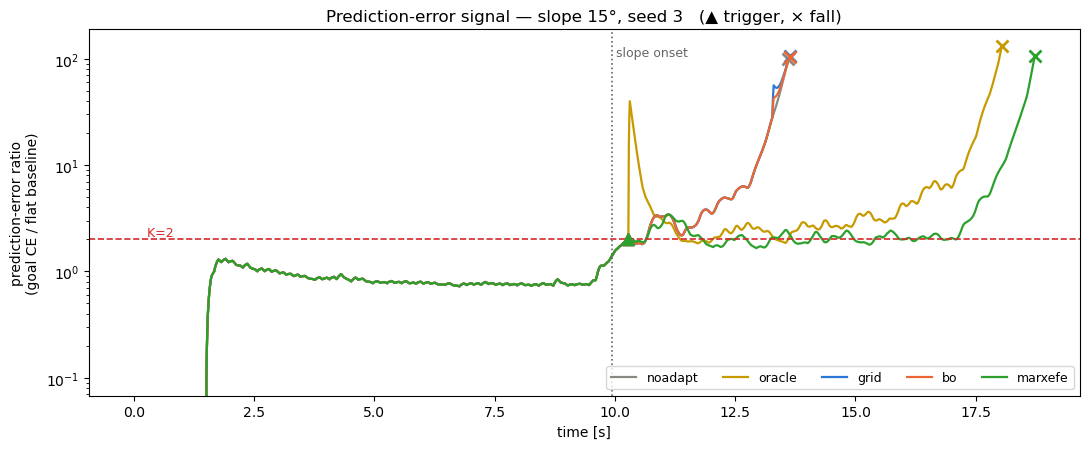

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.6))
for a in ARMS:
    r = runs[a]; t = r["t"]
    ax.plot(t, r["ratio"], color=COLOR[a], lw=1.6, label=a)
    kT = int(r["trigger_step"]);  kF = int(r["fall_step"])
    if kT >= 0:
        ax.plot(kT*DT, r["ratio"][kT], "^", color=COLOR[a], ms=9, zorder=5)
    if kF >= 0:
        ax.plot(kF*DT, r["ratio"][min(kF, len(t)-1)], "x", color=COLOR[a], ms=9, mew=2, zorder=5)
ax.axhline(K, color="tab:red", ls="--", lw=1.2)
ax.axvline(onset_t, color="0.4", ls=":", lw=1.2)
ax.text(onset_t, ax.get_ylim()[1]*0.96, " slope onset", color="0.4", fontsize=9, va="top")
ax.text(0.2, K, f" K={K:.2g}", color="tab:red", fontsize=9, va="bottom")
ax.set_yscale("log")
ax.set_xlabel("time [s]"); ax.set_ylabel("prediction-error ratio\n(goal CE / flat baseline)")
ax.set_title(f"Prediction-error signal — slope {SHOW_SLOPE:g}°, seed {SHOW_SEED}   "
             f"(▲ trigger, × fall)")
ax.legend(ncol=len(ARMS), fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

## 4. Body attitude — stability comparison

Low-passed roll (lateral bank — the dominant fall mode) and pitch (forward tilt)
per method for the same seed. A fall shows as roll running away to the × marker.

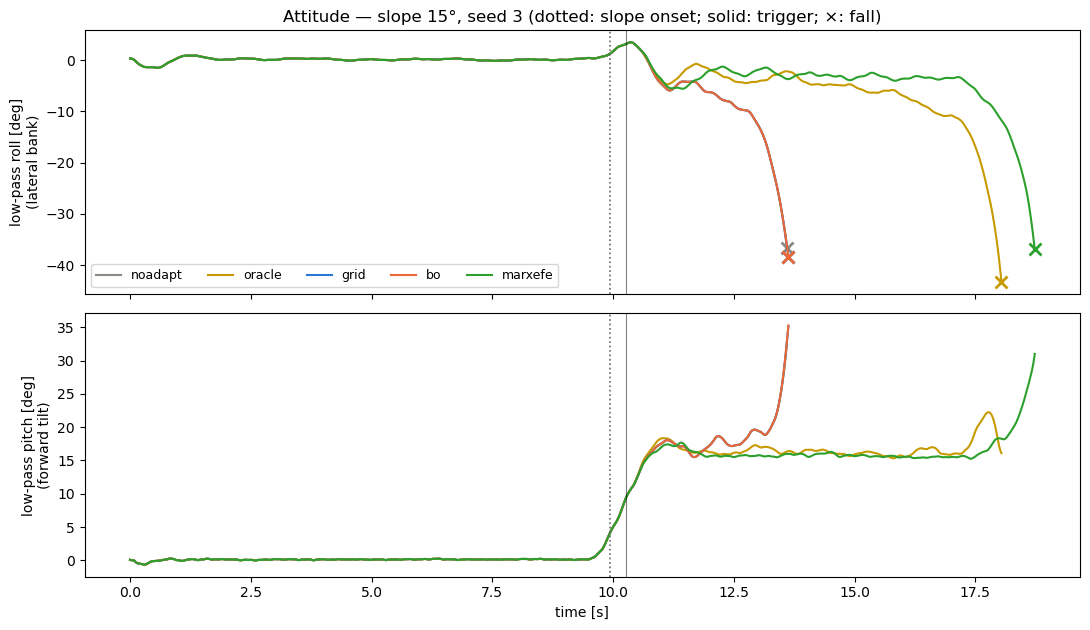

In [4]:
def _lowpass(x, w=50):
    x = np.asarray(x, float)
    if len(x) < 2: return x
    w = min(w, len(x)); c = np.concatenate([[0.0], np.cumsum(x)])
    return np.array([(c[min(i+1,len(x))]-c[max(0,i-w+1)])/(min(i+1,len(x))-max(0,i-w+1))
                     for i in range(len(x))])

fig, axs = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True)
for a in ARMS:
    r = runs[a]; t = r["t"]
    axs[0].plot(t, np.rad2deg(_lowpass(r["roll"])),  color=COLOR[a], lw=1.5, label=a)
    axs[1].plot(t, np.rad2deg(_lowpass(r["pitch"])), color=COLOR[a], lw=1.5, label=a)
    kF = int(r["fall_step"])
    if kF >= 0:
        axs[0].plot(kF*DT, np.rad2deg(_lowpass(r["roll"]))[min(kF,len(t)-1)], "x",
                    color=COLOR[a], ms=9, mew=2)
for ax in axs:
    ax.axvline(onset_t, color="0.4", ls=":", lw=1.2)
    if int(r0["trigger_step"]) >= 0:
        ax.axvline(int(r0["trigger_step"])*DT, color="k", ls="-", lw=0.8, alpha=0.5)
axs[0].set_ylabel("low-pass roll [deg]\n(lateral bank)")
axs[1].set_ylabel("low-pass pitch [deg]\n(forward tilt)")
axs[1].set_xlabel("time [s]")
axs[0].set_title(f"Attitude — slope {SHOW_SLOPE:g}°, seed {SHOW_SEED} "
                 f"(dotted: slope onset; solid: trigger; ×: fall)")
axs[0].legend(ncol=len(ARMS), fontsize=9)
plt.tight_layout(); plt.show()

## 5. What each method does — CPG parameter trajectories θ(t)

The applied CPG parameters over time for the online searchers. Before the trigger
every method holds the flat-optimal incumbent (dashed grey); after the trigger
each searches differently. The slope-optimal reference is dotted gold.

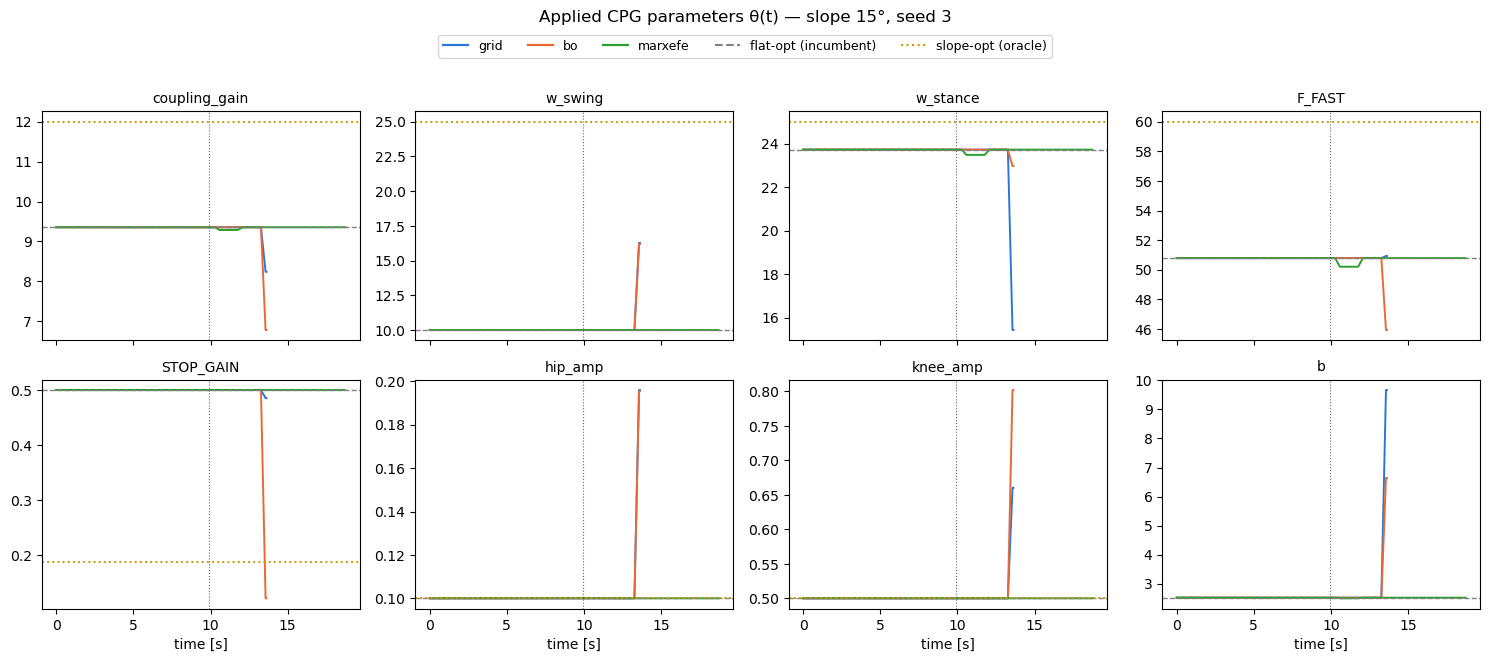

In [5]:
searchers = [a for a in ("grid", "bo", "marxefe") if a in ARMS]
inc = np.asarray(CFG["incumbent"], float); orc = np.asarray(CFG["oracle"], float)
fig, axs = plt.subplots(2, 4, figsize=(15, 6.2), sharex=True)
for j, ax in enumerate(axs.ravel()):
    for a in searchers:
        r = runs[a]
        ax.plot(r["t"], r["applied"][j], color=COLOR[a], lw=1.4, label=a)
    ax.axhline(inc[j], color="0.5", ls="--", lw=1.0)
    ax.axhline(orc[j], color="#c79a00", ls=":", lw=1.4)
    ax.axvline(onset_t, color="0.4", ls=":", lw=0.8)
    ax.set_title(PARAM_NAMES[j], fontsize=10)
    if j >= 4: ax.set_xlabel("time [s]")
handles = [Line2D([], [], color=COLOR[a], lw=1.6, label=a) for a in searchers]
handles += [Line2D([], [], color="0.5", ls="--", label="flat-opt (incumbent)"),
            Line2D([], [], color="#c79a00", ls=":", label="slope-opt (oracle)")]
fig.legend(handles=handles, loc="upper center", ncol=len(handles), fontsize=9,
           bbox_to_anchor=(0.5, 1.03))
fig.suptitle(f"Applied CPG parameters θ(t) — slope {SHOW_SLOPE:g}°, seed {SHOW_SEED}",
             y=1.06)
plt.tight_layout(); plt.show()

## 6. Window objective and when each method is adapting vs. paused

Per-window stability objective `J_stab` (higher is better; a fall scores −2) for
the online searchers, and the shaded bands show when each method is actively
proposing (adapting) vs. paused after squashing the error.

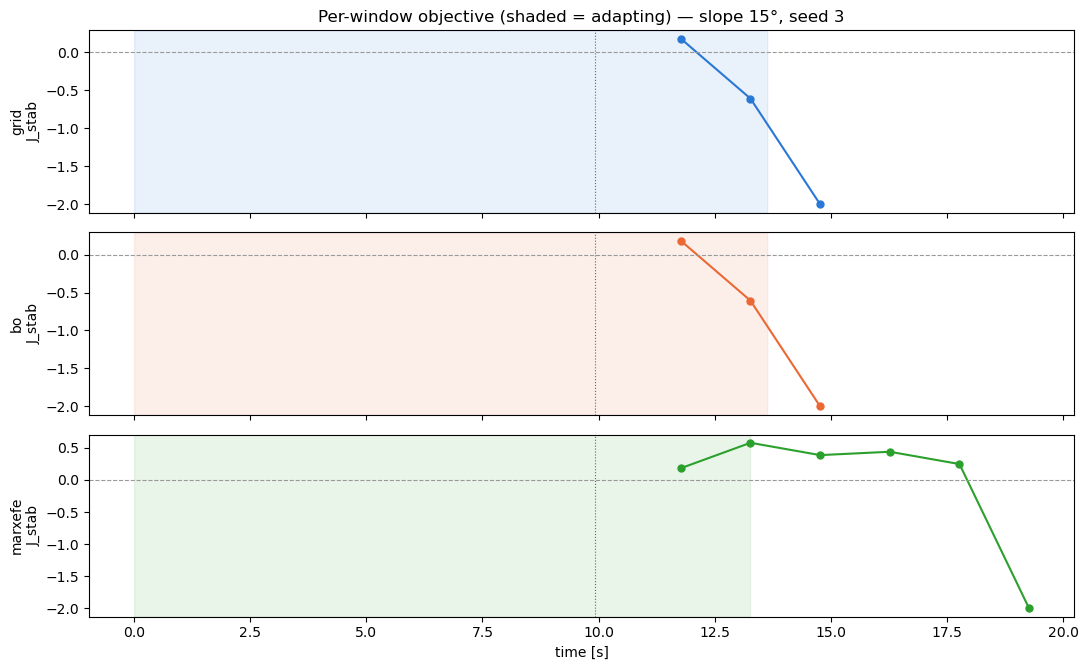

In [6]:
fig, axs = plt.subplots(len(searchers), 1, figsize=(11, 2.1*len(searchers)+0.5),
                        sharex=True, squeeze=False)
axs = axs[:, 0]
for ax, a in zip(axs, searchers):
    r = runs[a]; t = r["t"]; kT = int(r["trigger_step"])
    # adapting/paused shading
    adapt = r["adapting"].astype(bool)
    ax.fill_between(t, 0, 1, where=adapt, transform=ax.get_xaxis_transform(),
                    color=COLOR[a], alpha=0.10, step="mid", label="adapting")
    # window scores plotted at window-boundary times
    ws = r["window_scores"]
    if kT >= 0 and len(ws):
        tw = kT*DT + np.arange(1, len(ws)+1) * CFG["window"] * DT
        ax.plot(tw, ws, "o-", color=COLOR[a], lw=1.5, ms=5)
    ax.axhline(0.0, color="0.6", lw=0.8, ls="--")
    ax.axvline(onset_t, color="0.4", ls=":", lw=0.8)
    ax.set_ylabel(f"{a}\nJ_stab")
axs[-1].set_xlabel("time [s]")
axs[0].set_title(f"Per-window objective (shaded = adapting) — slope {SHOW_SLOPE:g}°, "
                 f"seed {SHOW_SEED}")
plt.tight_layout(); plt.show()

## 7. Aggregate comparison across seeds

Mean over seeds, per slope and method. Only **triggered** runs contribute to
survival / objective / squash statistics; the fall rate is over triggered runs.
`no-trigger` runs (the flat gait coped and the error never crossed `K`) are
tallied separately.

                     n  n_notrig  fall_rate  t_surv  mean_J  best_J  squash_t  n_proposals  n_pauses
slope_deg method                                                                                    
10.0      bo       6.0       1.0        1.0    6.51   -0.52    0.38      0.64         3.20      0.20
          grid     6.0       1.0        1.0    7.14   -0.40    0.39      0.64         3.60      0.20
          marxefe  6.0       1.0        1.0    9.11   -0.45    0.36      0.51         3.20      0.40
          noadapt  6.0       1.0        1.0    9.27   -0.41    0.38      0.64         3.20      0.40
          oracle   6.0       1.0        1.0   11.81   -0.27    0.58      0.65         4.60      0.40
15.0      bo       6.0       0.0        1.0    4.07   -0.77    0.00      0.46         3.17      0.00
          grid     6.0       0.0        1.0    3.82   -0.81   -0.02      0.46         3.00      0.00
          marxefe  6.0       0.0        1.0    5.44   -0.74   -0.21      0.26         1.83 

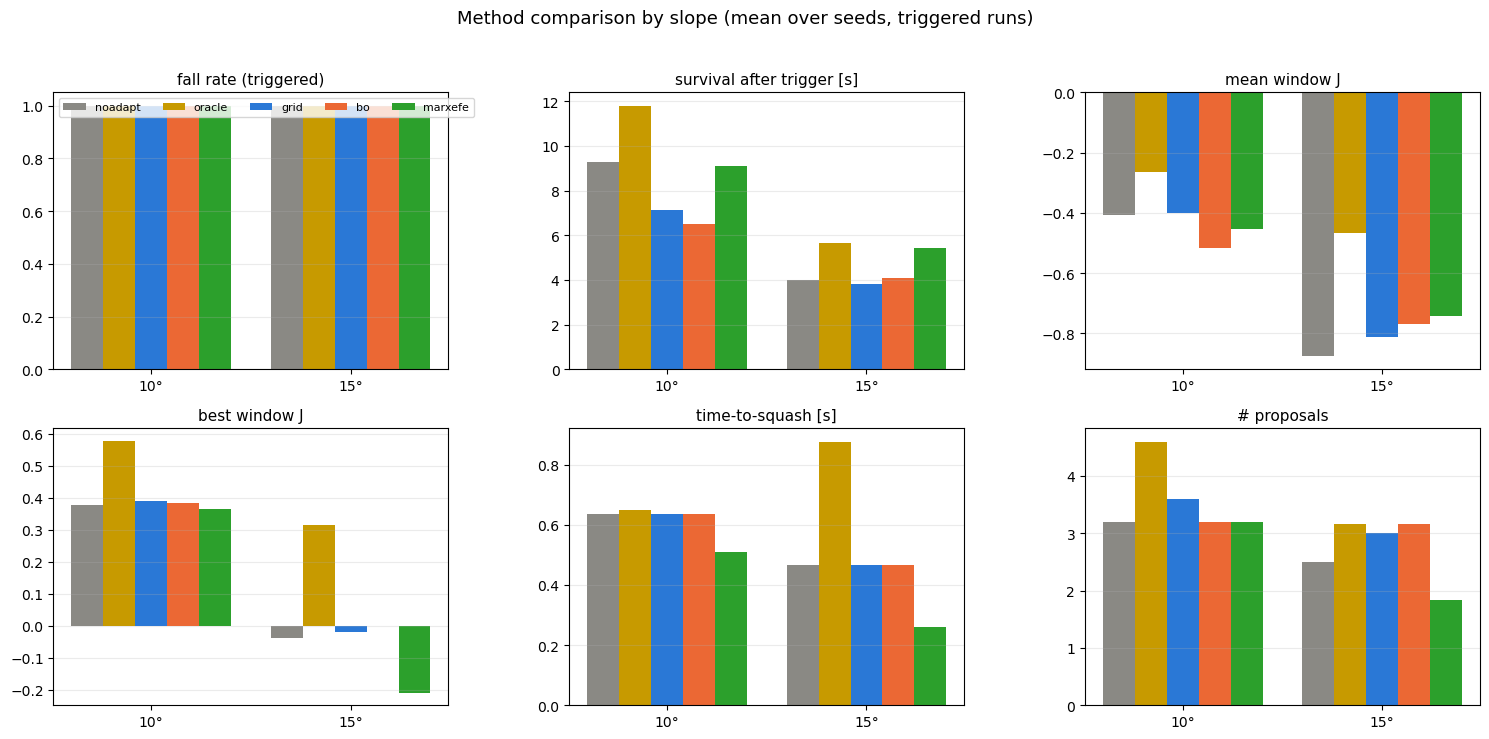

In [7]:
def agg(df):
    t = df[df.triggered == 1]
    return pd.Series(dict(
        n=len(df), n_notrig=int((df.triggered == 0).sum()),
        fall_rate=(t.fell.mean() if len(t) else np.nan),
        t_surv=t.t_surv.mean(), mean_J=t.mean_J.mean(), best_J=t.best_J.mean(),
        squash_t=t.squash_t.mean(), n_proposals=t.n_proposals.mean(),
        n_pauses=t.n_pauses.mean()))

table = (manifest.groupby(["slope_deg", "method"]).apply(agg)
         .reset_index().set_index(["slope_deg", "method"]))
pd.set_option("display.width", 160)
print(table.round(2))

metrics = [("fall_rate", "fall rate (triggered)", False),
           ("t_surv", "survival after trigger [s]", True),
           ("mean_J", "mean window J", True),
           ("best_J", "best window J", True),
           ("squash_t", "time-to-squash [s]", False),
           ("n_proposals", "# proposals", False)]
fig, axs = plt.subplots(2, 3, figsize=(15, 7.5))
x = np.arange(len(SLOPES)); w = 0.8/len(ARMS)
for ax, (col, lab, _) in zip(axs.ravel(), metrics):
    for i, a in enumerate(ARMS):
        vals = [table.loc[(sl, a), col] if (sl, a) in table.index else np.nan
                for sl in SLOPES]
        ax.bar(x + i*w, vals, w, color=COLOR[a], label=a)
    ax.set_xticks(x + w*(len(ARMS)-1)/2)
    ax.set_xticklabels([f"{sl:g}°" for sl in SLOPES])
    ax.set_title(lab, fontsize=11); ax.grid(alpha=0.25, axis="y")
axs[0, 0].legend(ncol=len(ARMS), fontsize=8, loc="upper left")
fig.suptitle("Method comparison by slope (mean over seeds, triggered runs)",
             fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

## 8. Takeaway

- The MARX-EFE prediction-error ratio is a clean, self-contained **event
  trigger**: ≈1 on the flat prefix, crossing `K` shortly after the robot meets
  the incline, and it **re-arms** so a method can be paused and resumed.
- On the trigger the online methods (`grid` / `bo` / `marxefe`) each start
  proposing new CPG parameters; the θ(t) panels show *how* they move, and the
  window-J / adapting panels show them **squashing** the error and then pausing.
- The aggregate panel compares them per slope: at gentle inclines the searchers
  recover; at steep inclines beyond the open-loop feasibility envelope even the
  slope-optimal `oracle` falls, which upper-bounds what any parameter switch can
  achieve. Re-run `run_experiment.py` with more `--seeds` / `--slopes` to tighten
  these statistics.